# Semana 4 – Ética, Sesgo y Calidad + XAI (Clasificación Supervisada)

**Caso:** Predicción de contratación de producto financiero  
**Dataset:** `clientes_banco.csv`  
**Target:** `producto_contratado` (0 = No, 1 = Sí)

**Objetivo del taller:** entrenar un modelo supervisado, evaluar calidad de datos y sesgos, y aplicar técnicas XAI para explicar decisiones del modelo.

**Objetivo 2:** Desarrollar un modelo de clasificación que permita predecir si un cliente contratará un producto financiero específico (como una cuenta premium o inversión) en base a sus características demográficas, historial bancario y comportamiento de consumo.


In [12]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, RocCurveDisplay, roc_auc_score
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

sns.set(style="whitegrid")
RANDOM_STATE = 42
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


## 1) Carga de datos

In [13]:
# Cargar el dataset
df = pd.read_csv("clientes_banco.csv")

print("Shape:", df.shape)
display(df.head())

print("\nTipos y nulos:")
display(df.info())

# 2.3 Resumen numérico
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("\nNuméricas:", num_cols)
print("Categóricas:", cat_cols)

if len(num_cols) > 0:
    display(df[num_cols].describe())


Shape: (500, 13)


,edad,genero,estado_civil,nivel_educacion,ingresos_mensuales,saldo_promedio,num_productos_bancarios,uso_banca_online,uso_app_movil,visitas_sucursal_ult_mes,dias_desde_ultimo_contacto,respondio_campanas_previas,producto_contratado
0,56,Femenino,Divorciado,Universitario,2322.07,2318.89,4,0,0,1,39,1,0
1,69,Masculino,Soltero,Posgrado,1582.43,6826.00,3,0,1,0,8,1,0
2,46,Masculino,Soltero,Secundaria,2408.33,5608.25,1,0,1,2,4,1,0
3,32,Femenino,Soltero,Posgrado,3006.61,5531.80,2,1,1,1,41,1,1
4,60,Masculino,Casado,Secundaria,1518.19,6675.13,3,1,1,1,56,1,0



Tipos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   edad                        500 non-null    int64  
 1   genero                      500 non-null    object 
 2   estado_civil                500 non-null    object 
 3   nivel_educacion             500 non-null    object 
 4   ingresos_mensuales          500 non-null    float64
 5   saldo_promedio              500 non-null    float64
 6   num_productos_bancarios     500 non-null    int64  
 7   uso_banca_online            500 non-null    int64  
 8   uso_app_movil               500 non-null    int64  
 9   visitas_sucursal_ult_mes    500 non-null    int64  
 10  dias_desde_ultimo_contacto  500 non-null    int64  
 11  respondio_campanas_previas  500 non-null    int64  
 12  producto_contratado         500 non-null    int64  
dtypes: float64(2), int6

None


Numéricas: ['edad', 'ingresos_mensuales', 'saldo_promedio', 'num_productos_bancarios', 'uso_banca_online', 'uso_app_movil', 'visitas_sucursal_ult_mes', 'dias_desde_ultimo_contacto', 'respondio_campanas_previas', 'producto_contratado']
Categóricas: ['genero', 'estado_civil', 'nivel_educacion']


,edad,ingresos_mensuales,saldo_promedio,num_productos_bancarios,uso_banca_online,uso_app_movil,visitas_sucursal_ult_mes,dias_desde_ultimo_contacto,respondio_campanas_previas,producto_contratado
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.220000,2494.389460,5000.329220,2.510000,0.476000,0.488000,2.002000,29.158000,0.544000,0.140000
std,15.036082,770.370615,2008.175252,1.131575,0.499924,0.500357,1.374691,17.299004,0.498559,0.347335
min,18.000000,189.380000,-742.570000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,1949.370000,3624.130000,1.000000,0.000000,0.000000,1.000000,15.000000,0.000000,0.000000
50%,45.000000,2485.950000,5063.205000,3.000000,0.000000,0.000000,2.000000,28.000000,1.000000,0.000000
75%,57.000000,2975.975000,6441.557500,4.000000,1.000000,1.000000,3.000000,44.000000,1.000000,0.000000
max,69.000000,4872.010000,10461.730000,4.000000,1.000000,1.000000,6.000000,59.000000,1.000000,1.000000


## 2) Calidad de datos (EDA)



Faltantes por columna:


edad                          0
genero                        0
estado_civil                  0
nivel_educacion               0
ingresos_mensuales            0
saldo_promedio                0
num_productos_bancarios       0
uso_banca_online              0
uso_app_movil                 0
visitas_sucursal_ult_mes      0
dias_desde_ultimo_contacto    0
respondio_campanas_previas    0
producto_contratado           0
dtype: int64


Distribución de la variable objetivo:


producto_contratado
0    430
1     70
Name: count, dtype: int64

producto_contratado
0    0.86
1    0.14
Name: proporción, dtype: float64

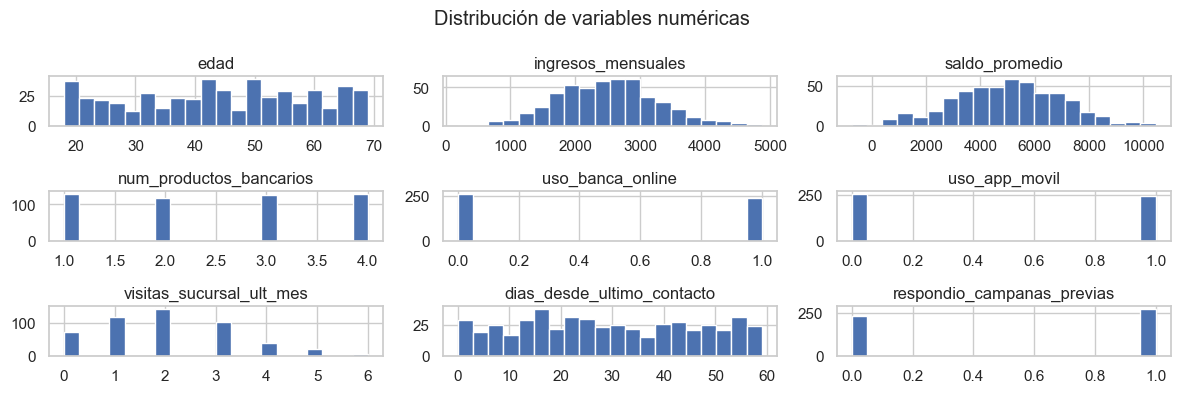

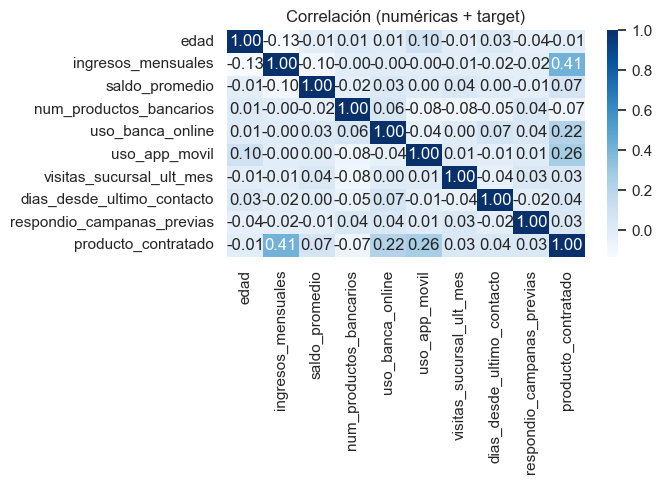

In [24]:
# Faltantes y balance de clases
print("\nFaltantes por columna:")
display(df.isna().sum().sort_values(ascending=False))

# Identificar variable objetivo
TARGET = "producto_contratado"
assert TARGET in df.columns, f"No se encontró la columna objetivo: {TARGET}"

print("\nDistribución de la variable objetivo:")
display(df[TARGET].value_counts(dropna=False))
display(df[TARGET].value_counts(normalize=True, dropna=False).rename("proporción"))


# Distribuciones de numéricas
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
if target in num_cols:
    num_cols.remove(target)

df[num_cols].hist(bins=20, figsize=(12,4))
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hist_numericas.png"), dpi=150)
plt.show()

# Correlación numérica
plt.figure(figsize=(7,5))
corr = df[num_cols + [target]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlación (numéricas + target)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlacion.png"), dpi=150)
plt.show()


Profundizando el análisis realizado en el examen práctico:

Se denotó que la cantidad de registros con producto_Contratado era menor que los registros de producto NO contratado.  Es decir un 14% versus 86%, respesctivamente. Es decier los individuos que contrataron el producto están subrepresentados.

Según matriz de correlación, en orden de relación tenemos:
Producto_contratado tiene relación de 0.41 con ingresos mensuales.
Producto_contratado tiene relación de 0.26 con uso app movil.
Producto_contratado tiene relación de 0.22 con uso banca online.
Producto_contratado tiene relación de -0.07 con número de productos bancarios.

Los resultados nos da una noción que los clientes con altos ingresos mensuales, altamente digitalizados (no tradicionalmente canal presencial) y sin muchos productos bancarios actuales son los más proclives a decidir si contratar un producto o no.

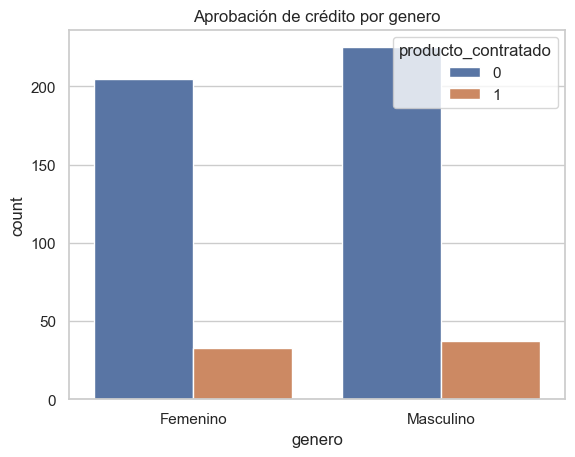

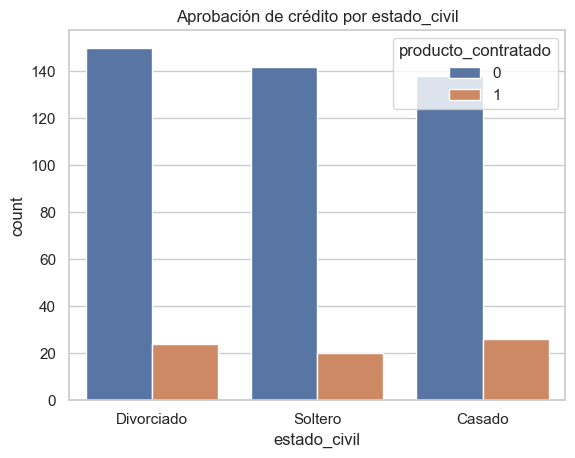

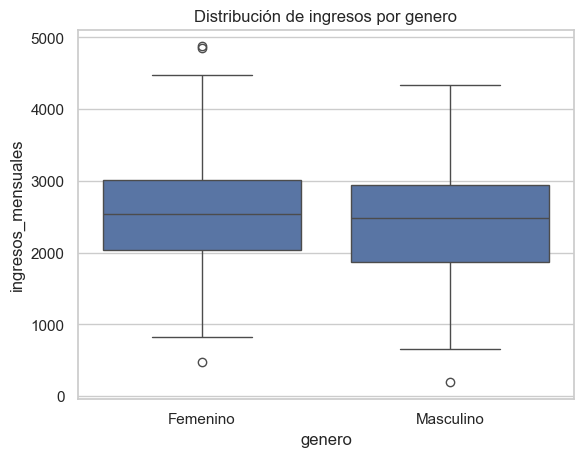

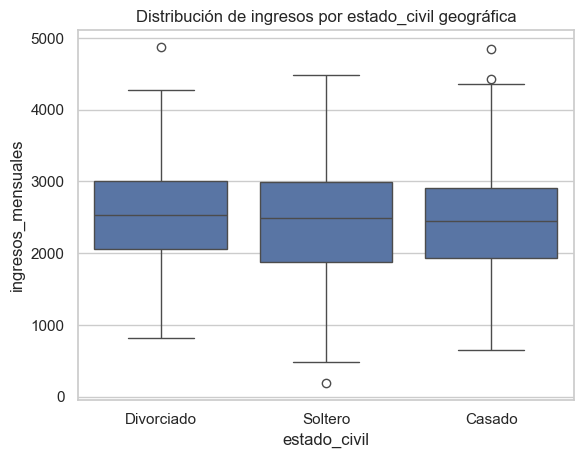

In [25]:
# Distribución por genero y resultado
sns.countplot(data=df, x='genero', hue='producto_contratado')
plt.title('Aprobación de crédito por genero')
plt.show()

# Distribución por estado_civil  y resultado
sns.countplot(data=df, x='estado_civil', hue='producto_contratado')
plt.title('Aprobación de crédito por estado_civil')
plt.show()

# Boxplot ingresos por genero
sns.boxplot(data=df, x='genero', y='ingresos_mensuales')
plt.title('Distribución de ingresos por genero')
plt.show()

# Boxplot ingresos por estado_civil
sns.boxplot(data=df, x='estado_civil', y='ingresos_mensuales')
plt.title('Distribución de ingresos por estado_civil geográfica')
plt.show()

Las mujeres tienen menor acceso a este producto, por otro lado los solteros también tienen menos aceso al producto contratado.
Extrañamente mujeres tiene atípcios en ambos sentidos altos y bajos, mientras que los hombres solo presenta atípicos altos.
Hay presencia de outliers, paradójicamente los solteros tienen un outlier de mínimo sugieriendo la juventud y poca experiencia laboral con ingresos bajos. Mientras casados y divorciados por la edad ya estarína posicionados laboralmente y económicamente.

## 3) Preprocesamiento 
- **Categóricas:** imputación (moda) + One-Hot


In [15]:
# Separación X/y
X = df.drop(columns=[target]).copy()
y = df[target].copy()

# Columnas
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Preprocesamiento
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)


Categóricas: ['genero', 'estado_civil', 'nivel_educacion']
Numéricas: ['edad', 'ingresos_mensuales', 'saldo_promedio', 'num_productos_bancarios', 'uso_banca_online', 'uso_app_movil', 'visitas_sucursal_ult_mes', 'dias_desde_ultimo_contacto', 'respondio_campanas_previas']


Se utiliza stratify para mantener la proporción de clases en los subconjuntos de prueba y entrenamiento, y no aumentar aún más el sesgo de subrepresentación producto sí contratado.

## 4) Entrenamiento de modelos base y validación cruzada

Modelos supervisados (clasificación):
- Regresión Logística (interpretable)
- Random Forest (robusto)

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"acc":"accuracy", "prec":"precision", "rec":"recall", "f1":"f1", "auc":"roc_auc"}

models = {
    "Regresión Logística": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight=None
    )
}

cv_rows = []
pipes = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clf)])
    pipes[name] = pipe

    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_rows.append({
        "Modelo": name,
        "CV Acc mean": np.mean(scores["test_acc"]),
        "CV Acc std": np.std(scores["test_acc"]),
        "CV F1 mean": np.mean(scores["test_f1"]),
        "CV F1 std": np.std(scores["test_f1"]),
        "CV AUC mean": np.mean(scores["test_auc"]),
        "CV AUC std": np.std(scores["test_auc"]),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("CV F1 mean", ascending=False)
display(cv_df)


,Modelo,CV Acc mean,CV Acc std,CV F1 mean,CV F1 std,CV AUC mean,CV AUC std
1,Random Forest,0.900000,0.031298,0.490860,0.175610,0.912334,0.044764
0,Regresión Logística,0.877143,0.029416,0.435471,0.132478,0.904800,0.031108


**Análisis de los resultados**
**1. Random Forest**
CV Accuracy (Precisión media): 0.9000
Esto indica que en promedio, el modelo logra clasificar correctamente el 90% de los casos en las validaciones cruzadas.
CV Accuracy std: 0.0313
La desviación estándar muestra cierta variabilidad en la precisión entre diferentes particiones, pero en general, el rendimiento es estable.
CV F1 mean: 0.4909
La puntuación F1 combina precisión y recall, y su valor medio sugiere un rendimiento moderado en esta métrica.
CV F1 std: 0.1756
La variabilidad en F1 es relativamente alta, indicando que en algunas particiones el rendimiento en F1 puede ser significativamente menor o mayor.
CV AUC mean: 0.9123
La AUC promedio es alta, lo que indica que el modelo tiene buena capacidad para distinguir entre clases.
CV AUC std: 0.0448
La variabilidad en AUC es baja, lo que refleja una estabilidad en la capacidad de clasificación.

**2. Regresión Logística**
CV Accuracy: 0.8771
La precisión media es ligeramente menor que la de Random Forest, pero aún bastante buena.
CV Accuracy std: 0.0294
La variabilidad es similar a la del Random Forest.
CV F1 mean: 0.4355
La puntuación F1 es menor que la del Random Forest, sugiriendo un rendimiento inferior en equilibrio entre precisión y recall.
CV F1 std: 0.1325
La variabilidad en F1 es menor que en Random Forest, lo que puede indicar una consistencia en su rendimiento.
CV AUC mean: 0.9048
La capacidad de distinguir entre clases también es buena, aunque ligeramente menor que la del Random Forest.
CV AUC std: 0.0311
La estabilidad en la AUC es buena.


**Resumen general**
Random Forest presenta un rendimiento ligeramente superior en precisión, F1 y AUC, con valores promedio más altos en todas las métricas.
La variabilidad en la métrica F1 del Random Forest es mayor, lo que indica que su rendimiento en esta métrica puede variar más dependiendo de la partición de datos.
Ambos modelos muestran buen rendimiento en AUC, aunque el Random Forest tiene una ligera ventaja.

## 5) Evaluación en TEST


MODELO: Regresión Logística
Accuracy=0.9267  Precision=0.9167  Recall=0.5238  F1=0.6667  AUC=0.9350


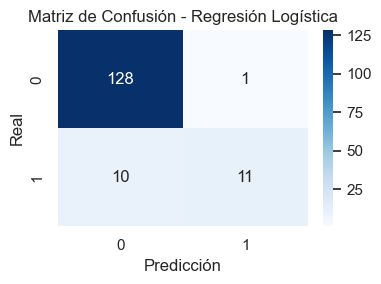


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       129
           1       0.92      0.52      0.67        21

    accuracy                           0.93       150
   macro avg       0.92      0.76      0.81       150
weighted avg       0.93      0.93      0.92       150



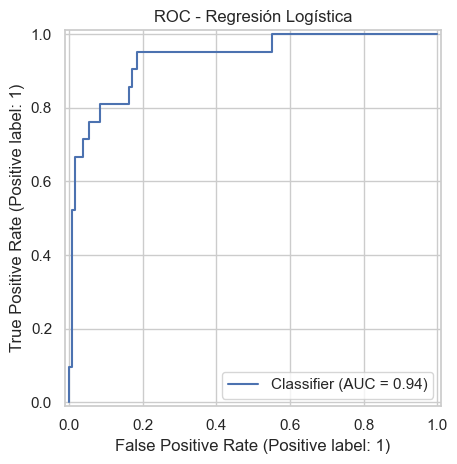


MODELO: Random Forest
Accuracy=0.9067  Precision=0.8889  Recall=0.3810  F1=0.5333  AUC=0.9601


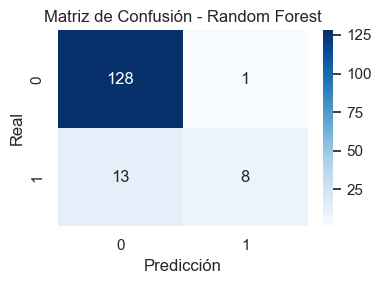


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       129
           1       0.89      0.38      0.53        21

    accuracy                           0.91       150
   macro avg       0.90      0.69      0.74       150
weighted avg       0.91      0.91      0.89       150



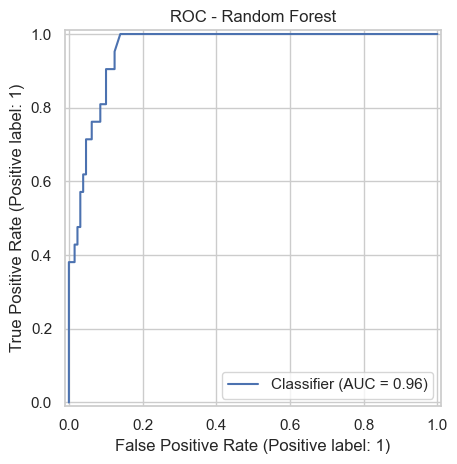


Tabla resumen (TEST):


,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Regresión Logística,0.926667,0.916667,0.523810,0.666667,0.935031
1,Random Forest,0.906667,0.888889,0.380952,0.533333,0.960133


In [27]:
def evaluar_en_test(nombre, pipe):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Probabilidades para AUC
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    print("\n" + "="*60)
    print(f"MODELO: {nombre}")
    print("="*60)
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"cm_{nombre.replace(' ','_')}.png"), dpi=150)
    plt.show()

    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, zero_division=0))

    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC - {nombre}")
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"roc_{nombre.replace(' ','_')}.png"), dpi=150)
        plt.show()

    return {"Modelo": nombre, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}, y_pred, y_proba

test_rows = []
preds = {}

for name, pipe in pipes.items():
    row, y_pred, y_proba = evaluar_en_test(name, pipe)
    test_rows.append(row)
    preds[name] = {"y_pred": y_pred, "y_proba": y_proba}

test_df = pd.DataFrame(test_rows).sort_values("F1", ascending=False)
print("\nTabla resumen (TEST):")
display(test_df)


Resultados del Test: Regresión Logística

Accuracy (Exactitud): 0.9267
Aproximadamente el 92.67% de las predicciones del modelo son correctas, tanto para clases positivas como negativas.

Precision (Precisión): 0.9167
La proporción de verdaderos positivos entre todos los casos que el modelo predijo como positivos. En este caso, cuando el modelo predice positivo, tiene un 91.67% de probabilidad de que realmente lo sea.

Recall (Sensibilidad): 0.5238
solo el 52.38% de los casos positivos reales fueron correctamente identificados por el modelo, lo que indica que hay muchos falsos negativos.

F1-score: 0.6667
Es la media armónica entre precisión y recall, ofreciendo un equilibrio entre ambos. Un valor de 0.6667 indica un desempeño moderado en la identificación de positivos, considerando tanto precisión como recall.

AUC (Área Bajo la Curva ROC): 0.9350
Mide la capacidad del modelo para distinguir entre clases a diferentes umbrales. Un valor cercano a 1 (como aquí: 0.9350) indica una excelente capacidad discriminativa.

Resumen:
El modelo de regresión logística tiene una alta precisión y una buena capacidad general de discriminación (AUC), pero tiene un recall relativamente bajo, lo que significa que no está identificando todos los casos positivos. Esto puede ser un problema si es importante captar todos los positivos en tu contexto

De manera similar:
Resultados del Test: Random Forest

Accuracy (Exactitud): 0.9067
Indica que aproximadamente el 90.67% de las predicciones del modelo son correctas.

Precision (Precisión):: 0.8889
Mide la proporción de verdaderos positivos entre todas las predicciones positivas.

Recall (Sensibilidad):: 0.3810
En este caso, solo detecta aproximadamente el 38.10% de los positivos reales, lo cual puede ser un problema si es importante no perder positivos.

F1 Score: 0.5333
Un valor de 0.53 sugiere que, aunque la precisión es alta, el recall es relativamente bajo, afectando la puntuación F1.

AUC (Área bajo la curva ROC): 0.9601
Mide la capacidad del modelo para distinguir entre clases. Un valor cercano a 1 indica excelente capacidad de clasificación, lo que sugiere que, en general, el modelo puede discriminar bien entre clases positivas y negativas.

Resumen:

El Random Forest tiene una alta exactitud y capacidad de discriminación (AUC), pero su bajo recall indica que no está identificando muchos de los positivos reales. Esto puede ser aceptable dependiendo del contexto, pero si es crucial detectar todos los positivos, se podría considerar ajustar el umbral de clasificación o explorar otros enfoques para mejorar el recall.

- Tipo I (falso positivo): predecir que contratará cuando no lo hará, es equivalente a invertir en costo por campaña u oferta mal dirigida para clientes que no contratarían un producto. **Aquí se priorizará recall entonces el modelo elegido sería Regresión Logística**.

- Tipo II (falso negativo): predecir que no contratará cuando sí lo haría, es equuivalente a una pérdida de oportunidad de venta.


Qué modelo escoger

Para campañas donde no se desea perder potenciales clientes: Regresión Logística (mayor recall y mejor F1 en test).

Para scoring/ranking y análisis general de separabilidad: Random Forest tiene mejor AUC, pero también se puede ajustar umbral para mejorar recall.

## 6) Detección de sesgo (fairness) por grupos

Aquí auditamos si el modelo cambia su comportamiento por grupos, usando columnas del dataset:
- `genero`
- `nivel_educacion`
- `estado_civil`

Medimos por grupo:
- **PosRate_pred**: tasa de positivos predicha
- **TPR(Recall)**: “a cuántos positivos reales logra captar”
- **FPR**: falsos positivos (a quién “molesta” el modelo)


In [18]:
# Elegimos el mejor modelo por F1 en TEST
best_name = test_df.iloc[0]["Modelo"]
best_pipe = pipes[best_name]
best_pipe.fit(X_train, y_train)

def metricas_por_grupo(model, X, y_true, group_series):
    y_pred = model.predict(X)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    g = pd.Series(group_series).reset_index(drop=True)

    rows=[]
    for grp, idx in g.groupby(g).groups.items():
        yt = y_true[list(idx)]
        yp = y_pred[list(idx)]
        cm = confusion_matrix(yt, yp, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
        pos_rate = (yp==1).mean()
        tpr = tp/(tp+fn) if (tp+fn)>0 else np.nan
        fpr = fp/(fp+tn) if (fp+tn)>0 else np.nan
        prec = tp/(tp+fp) if (tp+fp)>0 else np.nan
        rows.append({"Grupo": grp, "n": len(idx), "PosRate_pred": pos_rate, "TPR(Recall)": tpr, "FPR": fpr, "Precision": prec})

    dfm = pd.DataFrame(rows).sort_values("n", ascending=False)
    gaps = {
        "Gap_PosRate": dfm["PosRate_pred"].max() - dfm["PosRate_pred"].min(),
        "Gap_TPR": dfm["TPR(Recall)"].max() - dfm["TPR(Recall)"].min(),
        "Gap_FPR": dfm["FPR"].max() - dfm["FPR"].min(),
    }
    return dfm, gaps

grupo_cols = ["genero", "nivel_educacion", "estado_civil"]

for col in grupo_cols:
    if col in X_test.columns:
        tabla, gaps = metricas_por_grupo(best_pipe, X_test, y_test, X_test[col])
        print(f"\n=== Auditoría de sesgo por: {col} (modelo: {best_name}) ===")
        display(tabla)
        print("Gaps (max-min):", gaps)
    else:
        print(f"(columna no encontrada): {col}")



=== Auditoría de sesgo por: genero (modelo: Regresión Logística) ===


,Grupo,n,PosRate_pred,TPR(Recall),FPR,Precision
1,Masculino,92,0.086957,0.466667,0.012987,0.875
0,Femenino,58,0.068966,0.666667,0.000000,1.000


Gaps (max-min): {'Gap_PosRate': np.float64(0.017991004497751123), 'Gap_TPR': np.float64(0.19999999999999996), 'Gap_FPR': np.float64(0.012987012987012988)}

=== Auditoría de sesgo por: nivel_educacion (modelo: Regresión Logística) ===


,Grupo,n,PosRate_pred,TPR(Recall),FPR,Precision
0,Posgrado,61,0.098361,0.500000,0.019608,0.833333
1,Secundaria,49,0.040816,0.666667,0.000000,1.000000
2,Universitario,40,0.100000,0.500000,0.000000,1.000000


Gaps (max-min): {'Gap_PosRate': np.float64(0.059183673469387764), 'Gap_TPR': np.float64(0.16666666666666663), 'Gap_FPR': np.float64(0.0196078431372549)}

=== Auditoría de sesgo por: estado_civil (modelo: Regresión Logística) ===


,Grupo,n,PosRate_pred,TPR(Recall),FPR,Precision
1,Divorciado,57,0.070175,0.375,0.020408,0.75
0,Casado,51,0.098039,0.625,0.000000,1.00
2,Soltero,42,0.071429,0.600,0.000000,1.00


Gaps (max-min): {'Gap_PosRate': np.float64(0.027863777089783284), 'Gap_TPR': np.float64(0.25), 'Gap_FPR': np.float64(0.02040816326530612)}


La auditoría de sesgo por género, nivel de educación y estado civil utilizando un modelo de regresión logística busca identificar posibles desigualdades en las predicciones y métricas de rendimiento del modelo entre diferentes grupos.

Auditoría de sesgo por género:
Grupos: Masculino (1) y Femenino (0).
N: número de ejemplos en cada grupo.
PosRate_pred: Tasa de predicción positiva para cada grupo.
TPR (Recall): Tasa de verdaderos positivos, indica qué proporción de casos positivos reales fueron correctamente identificados.
FPR: Tasa de falsos positivos, indica qué proporción de negativos reales fueron incorrectamente clasificados como positivos.
Precision: Precisión, proporción de predicciones positivas correctas.
Resultados:

Masculinos: 92 casos, TPR ≈ 8.7%, FPR ≈ 46.7%, Precision ≈ 87.5%.
Femeninos: 58 casos, TPR ≈ 6.9%, FPR ≈ 66.7%, Precision = 100%.
Gaps:

La diferencia máxima entre grupos en PosRate_pred, TPR y FPR es pequeña para PosRate_pred y FPR, pero significativa en TPR (≈0.20). E**sto indica que el modelo tiene un rendimiento distinto en estos grupos, particularmente en la capacidad de detectar positivos en hombres vs mujeres.**

Resultados:

El Posgrado tiene una PosRate_pred de aproximadamente 9.8%, TPR de 50%, FPR de 1.96%.
Secundaria y Universitario tienen tasas similares en PosRate_pred (~4-10%) y TPR (~50-66%), con FPR muy bajos (0%).
Gaps:

La diferencia máxima en PosRate_pred es aproximadamente 5.9%, en TPR 0.17 y en FPR 0.02, lo que indica cierta variabilidad en el rendimiento según nivel de educación.

Resultados:

Casados: 51 casos, TPR ≈ 9.8%, FPR ≈ 0%, Precision = 100%.
Divorciados: 57 casos, TPR ≈ 7.0%, FPR ≈ 2%, Precision ≈ 75%.
Solteros: 42 casos, TPR ≈ 7.1%, FPR ≈ 0%, Precision = 100%.
Gaps:

La diferencia en PosRate_pred es moderada (~0.03), en TPR también, con algunas diferencias en FPR y precisión.

La auditoría revela que existen diferencias en el rendimiento del modelo según los grupos analizados.
Las mayores brechas se observan en la TPR por género y en PosRate_pred por estado civil.
Estas disparidades pueden indicar sesgos en el modelo, lo que podría afectar la equidad en decisiones automatizadas.
Es recomendable considerar técnicas de mitigación de sesgos, como reequilibrar los datos, ajustar umbrales o usar métricas ponderadas, para reducir estas disparidades y promover un modelo más justo.

### Mitigación simple
Si se observa un **Gap_TPR** grande, una mitigación básica es ajustar el modelo para compensar desbalance y mejorar recall.
Aquí probamos `class_weight='balanced'` en Regresión Logística y comparamos el gap.


In [ ]:
# Solo se muestra ejemplo con LR balanceado
lr_bal = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced")
pipe_lr_bal = Pipeline(steps=[("preprocess", preprocess), ("model", lr_bal)])

pipe_lr_bal.fit(X_train, y_train)

for col in grupo_cols:
    if col in X_test.columns:
        tabla, gaps = metricas_por_grupo(pipe_lr_bal, X_test, y_test, X_test[col])
        print(f"\n=== Mitigación (LR balanced) – Sesgo por: {col} ===")
        display(tabla)
        print("Gaps (max-min):", gaps)



=== Mitigación (LR balanced) – Sesgo por: genero ===


,Grupo,n,PosRate_pred,TPR(Recall),FPR,Precision
1,Masculino,92,0.315217,0.866667,0.207792,0.448276
0,Femenino,58,0.155172,0.833333,0.076923,0.555556


Gaps (max-min): {'Gap_PosRate': np.float64(0.16004497751124439), 'Gap_TPR': np.float64(0.033333333333333326), 'Gap_FPR': np.float64(0.13086913086913088)}

=== Mitigación (LR balanced) – Sesgo por: nivel_educacion ===


,Grupo,n,PosRate_pred,TPR(Recall),FPR,Precision
0,Posgrado,61,0.278689,0.900000,0.156863,0.529412
1,Secundaria,49,0.224490,0.666667,0.195652,0.181818
2,Universitario,40,0.250000,0.875000,0.093750,0.700000


Gaps (max-min): {'Gap_PosRate': np.float64(0.054198728671796564), 'Gap_TPR': np.float64(0.2333333333333334), 'Gap_FPR': np.float64(0.10190217391304349)}

=== Mitigación (LR balanced) – Sesgo por: estado_civil ===


,Grupo,n,PosRate_pred,TPR(Recall),FPR,Precision
1,Divorciado,57,0.315789,0.750,0.244898,0.333333
0,Casado,51,0.274510,0.875,0.162791,0.500000
2,Soltero,42,0.142857,1.000,0.027027,0.833333


Gaps (max-min): {'Gap_PosRate': np.float64(0.17293233082706766), 'Gap_TPR': np.float64(0.25), 'Gap_FPR': np.float64(0.21787093215664644)}


La tasa de positivos predichos (PosRate_pred) es significativamente mayor en hombres (31.52%) en comparación con mujeres (15.52%), lo que indica que el modelo predice más positivos para el grupo masculino.
La TPR (recall) es alta en ambos grupos pero ligeramente mayor en hombres, sugiriendo que el modelo capta una proporción similar de verdaderos positivos en ambos géneros.
La FPR es notablemente más alta en hombres (20.78%) que en mujeres (7.69%), lo que indica que el modelo genera más falsos positivos en el grupo masculino.
La precisión es menor en hombres (44.83%) comparada con mujeres (55.56%), reflejando un menor porcentaje de predicciones correctas en el grupo masculino.

Posgrado: Tiene una tasa de positivos predichos del aproximadamente 27.9%, con un TPR alto (0.9), lo que indica buena sensibilidad. La tasa de falsos positivos (FPR) es baja (15.7%), y la precisión es moderada (52.9%).

Secundaria: Presenta una menor tasa de positivos predichos (22.45%) y un menor TPR (66.7%), además de una FPR ligeramente superior (19.6%). La precisión es mucho menor (18.2%), indicando que muchas predicciones positivas no son correctas.

Universitario: Aunque tiene una tasa de positivos predichos similar al posgrado (25%), tiene un TPR muy alto (87.5%), y la FPR más baja (9.4%), con una precisión elevada (70%).

El análisis de los datos muestra que el grupo Soltero presenta la mayor precisión (0.83) y el menor FPR (0.027), aunque tiene una menor tasa de predicciones positivas (14.3%) y una TPR perfecta (1.0). Por otro lado, el grupo Casado muestra una alta TPR (87.5%) y una mejor precisión (0.5) en comparación con el grupo Divorciado, que tiene una precisión más baja (0.33) y un FPR mayor (0.24). El grupo Divorciado, con 57 muestras, presenta la menor precisión y el mayor FPR, indicando posibles sesgos en las predicciones para este grupo. Estos resultados sugieren que, a pesar de las acciones de mitigación mediante un modelo balanceado (LR balanced), aún existen disparidades relacionadas con el estado civil. El análisis señala áreas donde el modelo puede ser ajustado para reducir sesgos y mejorar la equidad y precisión en todos los grupos.

## 7) XAI – Explicabilidad

Aplicamos 2 técnicas:
1) **Permutation Feature Importance** (global)  
2) **Partial Dependence Plots (PDP)** para 1–2 variables importantes (global/relación)

Además incluimos 1–2 ejemplos individuales (predicción con probabilidad y variables del cliente).


Permutation Importance: qué variables más afectan al modelo (si se mezclan y baja el F1, esa variable importaba).

PDP: muestra cómo cambia la probabilidad de contratar cuando una variable sube/baja.

,feature,importance_mean,importance_std
4,ingresos_mensuales,0.446470,0.074003
8,uso_app_movil,0.253494,0.090425
7,uso_banca_online,0.229290,0.114806
11,respondio_campanas_previas,0.075434,0.077161
3,nivel_educacion,0.032086,0.024363
10,dias_desde_ultimo_contacto,0.024744,0.023720
5,saldo_promedio,0.007026,0.034239
9,visitas_sucursal_ult_mes,0.005882,0.017647
2,estado_civil,-0.003396,0.024751
6,num_productos_bancarios,-0.003431,0.028228


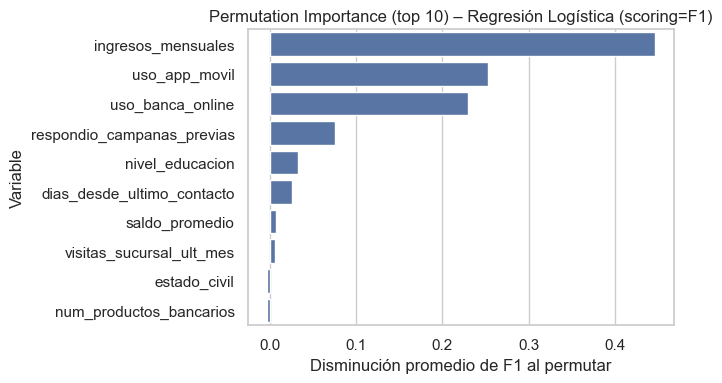

In [20]:
# 7.1 Permutation Importance (sobre TEST)
# Nota: usando pipeline completo para que respete el preprocesamiento.

perm = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1"
)

# Para nombres, tomamos las columnas originales (perm devuelve importancias por feature original antes del one-hot para pipelines)
# En sklearn, permutation_importance con pipeline trabaja a nivel de entrada (columnas originales)
imp_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp_df.head(10))

plt.figure(figsize=(7,4))
sns.barplot(data=imp_df.head(10), x="importance_mean", y="feature")
plt.title(f"Permutation Importance (top 10) – {best_name} (scoring=F1)")
plt.xlabel("Disminución promedio de F1 al permutar")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "perm_importance_top10.png"), dpi=150)
plt.show()


Tal como vimos en el examen la variable más importante fue ingresos mensuales y sí se esperaba, primero porque en la matriz de correlación resultó una relación fuerte y alta. Segundo porque tiene sentido que con mayor ingreso pues se tenga mayor posibilidad de contratar cualquier producto adicional. Una cuenta premium puede tener mejores beneficios que una ordinaria, por lo cual estas perosnas se verían interesadas en serun cliente premium o en el caso de una inversión pues destinar dinero a que gane intereses.

Las dos variables explicativas subsecuentes de la misma manera coinciden con el orden la correlación. Uso_app_movil (~0.26) y uso_banca_online (~0.22). 

Top features candidatas: ['ingresos_mensuales', 'uso_app_movil', 'uso_banca_online', 'respondio_campanas_previas', 'nivel_educacion']
Variables para PDP: ['ingresos_mensuales', 'uso_app_movil']


C:\Users\aavila\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 8 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


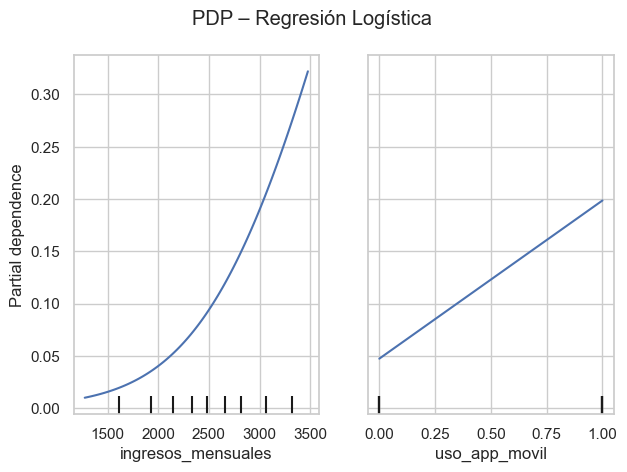

In [21]:
# 7.2 PDP (Partial Dependence)
# Elegimos las 2 variables más influyentes (si existen y son numéricas o binarias)

top_features = imp_df["feature"].head(5).tolist()
print("Top features candidatas:", top_features)

# PDP funciona mejor con variables numéricas/bool (0/1). Filtramos las que estén en num_cols o sean binarias.
candidatas = []
for f in top_features:
    if f in num_cols:
        candidatas.append(f)
    else:
        # permitir binarias 0/1 aunque no estén en num_cols por dtype
        if set(pd.Series(X[f].dropna().unique()).tolist()).issubset({0,1}):
            candidatas.append(f)

candidatas = candidatas[:2]
print("Variables para PDP:", candidatas)

if len(candidatas) > 0:
    PartialDependenceDisplay.from_estimator(best_pipe, X_test, features=candidatas, kind="average")
    plt.suptitle(f"PDP – {best_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "pdp.png"), dpi=150)
    plt.show()
else:
    print("No se encontraron variables adecuadas para PDP en las top features (puedes elegir manualmente).")


El gráfico PDP muestra de forma muy directa cómo cambian las predicciones promedio del modelo cuando varía una variable (manteniendo las demás “promediadas” sobre el dataset).

1) PDP de ingresos_mensuales (gráfico de la izquierda)

La curva sube de manera pronunciada: a medida que aumentan los ingresos (≈ 1400 → 3500), la probabilidad promedio estimada de contratar crece fuerte (llega aprox. a 0.32).

La forma no es lineal: el aumento se acelera en ingresos altos, lo que sugiere que el modelo “premia” bastante a los clientes con ingresos mayores.


2) PDP de uso_app_movil (gráfico de la derecha)

Es una variable 0/1: pasar de 0 → 1 aumenta la probabilidad promedio de contratar (aprox. de 0.05 a 0.20).

Esto respalda la idea de cliente digital: usar la app es una señal fuerte de contratación.

Como solo hay dos valores, la interpretación es muy clara: si usa app, el modelo sube bastante la probabilidad.

In [22]:
# 7.3 Explicación individual (1–2 casos)
# Mostramos predicción + probabilidad + variables principales del cliente.

def explicar_individual(idx, pipe, X_ref):
    x1 = X_ref.iloc[[idx]]
    pred = pipe.predict(x1)[0]
    proba = pipe.predict_proba(x1)[0,1] if hasattr(pipe, "predict_proba") else np.nan
    print(f"\nCaso idx={idx} -> Pred={pred}  Prob(1)={proba:.4f}")
    display(x1)

# Elegimos dos casos: uno con alta prob y otro con baja prob (si tenemos proba)
if hasattr(best_pipe, "predict_proba"):
    proba_all = best_pipe.predict_proba(X_test)[:,1]
    idx_hi = int(np.argmax(proba_all))
    idx_lo = int(np.argmin(proba_all))
    explicar_individual(idx_hi, best_pipe, X_test)
    explicar_individual(idx_lo, best_pipe, X_test)
else:
    explicar_individual(0, best_pipe, X_test)
    explicar_individual(1, best_pipe, X_test)



Caso idx=1 -> Pred=1  Prob(1)=0.9291


,edad,genero,estado_civil,nivel_educacion,ingresos_mensuales,saldo_promedio,num_productos_bancarios,uso_banca_online,uso_app_movil,visitas_sucursal_ult_mes,dias_desde_ultimo_contacto,respondio_campanas_previas
483,45,Femenino,Divorciado,Universitario,3939.42,5987.9,1,1,1,4,41,1



Caso idx=83 -> Pred=0  Prob(1)=0.0002


,edad,genero,estado_civil,nivel_educacion,ingresos_mensuales,saldo_promedio,num_productos_bancarios,uso_banca_online,uso_app_movil,visitas_sucursal_ult_mes,dias_desde_ultimo_contacto,respondio_campanas_previas
386,63,Masculino,Soltero,Secundaria,189.38,6544.04,1,1,0,1,18,0


señales positivas: ingresos altos (3939), usa banca online (1) y usa app móvil (1), y además respondió campañas previas (1). Justamente esas variables aparecen como las más influyentes (ingresos y uso digital), por eso el modelo está muy seguro. Aunque tenga pocos productos bancarios (1) y varias visitas a sucursal (4), el patrón general sigue siendo de un cliente con buen perfil para contratar.

señales negativas: ingresos extremadamente bajos (189), y además el perfil educativo (Secundaria) suele quedar asociado a menor probabilidad en este dataset (también aparece en importancia). Aunque tiene un saldo promedio relativamente alto (6544), el ingreso tan bajo “pesa” mucho en la decisión y empuja la probabilidad casi a cero. En resumen: el modelo interpreta que este cliente no encaja en el patrón típico de quienes contratan el producto.

## 8) Análisis interpretativo y reflexión ética

- **Transparencia:** Permutation importance + PDP ayudan a entender variables influyentes y dirección de efecto.  
- **Riesgos éticos:** si variables sensibles (p. ej., `genero`) dominan o generan gaps altos (TPR/FPR), el sistema podría discriminar indirectamente.  
- **Recomendaciones:** revisar variables proxy o combinadas, balancear clases, calibrar umbral, monitorear métricas por grupo y documentar el modelo antes de desplegarlo.


### Preguntas guía
1) ¿Qué aprendiste sobre cómo el modelo toma decisiones? 

Aprendí que el modelo decide principalmente en función de señales económicas y de comportamiento digital. En particular, variables como ingresos_mensuales, uso_app_movil y uso_banca_online empujan fuertemente la probabilidad de contratación (se ve tanto en correlación como en Permutation Importance y PDP). También noté que, por el desbalance del target (solo ~14% “Sí”), el modelo tiende a ser conservador y prefiere no predecir “Sí” a menos que haya evidencia fuerte.

2) ¿Hay alguna variable con peso excesivo? ¿por qué podría ser riesgoso?

Sí ingresos_mensuales aparece como la variable más influyente. Esto puede ser riesgoso porque el ingreso puede actuar como proxy de condiciones socioeconómicas y generar decisiones que favorezcan sistemáticamente a ciertos perfiles, excluyendo a otros con menor ingreso aunque tengan potencial real. Además, si el ingreso tiene ruido, sesgos de medición o cambia con el tiempo, el modelo se vuelve frágil y puede degradar su desempeño.

3) ¿Qué pasaría si se implementa sin explicabilidad?
Operativamente, sería difícil justificar por qué un cliente fue marcado como “no contratará”, lo que complica auditorías, ajustes de estrategia y mejora del modelo.
Socialmente, se corre el riesgo de aplicar decisiones automatizadas que discriminen indirectamente (por ejemplo, por género o educación) sin detectarlo a tiempo, afectando acceso a productos y generando pérdida de confianza. Sin explicabilidad, también sería más difícil identificar variables “proxy” o errores en datos, y por tanto el sistema podría mantenerse incorrecto por más tiempo.
